In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# q1 - Supervised Learning
# part 1 - Data loading and inspection

# Data Load
df = pd.read_csv("q1_heart_disease.csv")

# Shape of dataset
print("Shape of dataset:", df.shape)

# Data types
print("\nData types:\n", df.dtypes)

# Missing values
print("\nMissing values:\n", df.isnull().sum())

#Print first 5 rows
df.head()


Shape of dataset: (800, 12)

Data types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


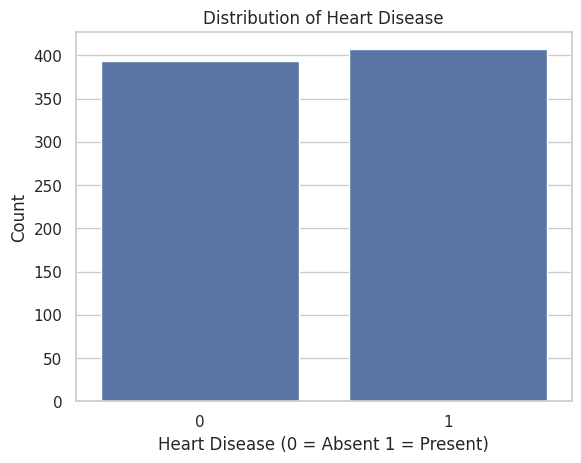

In [18]:
# part 2 - Exploratory Data Analytics

# viz 1 - Target Class Distribution

sns.set(style="whitegrid")
sns.countplot(x='heart_disease', data=df)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = Absent 1 = Present)")
plt.ylabel("Count")
plt.show()



## Interpretation of Target Distribution

The dataset shows the number of patients with and without heart disease.

- If balanced → model training is stable
- If imbalanced → may need special handling

This helps in understanding class distribution before modeling

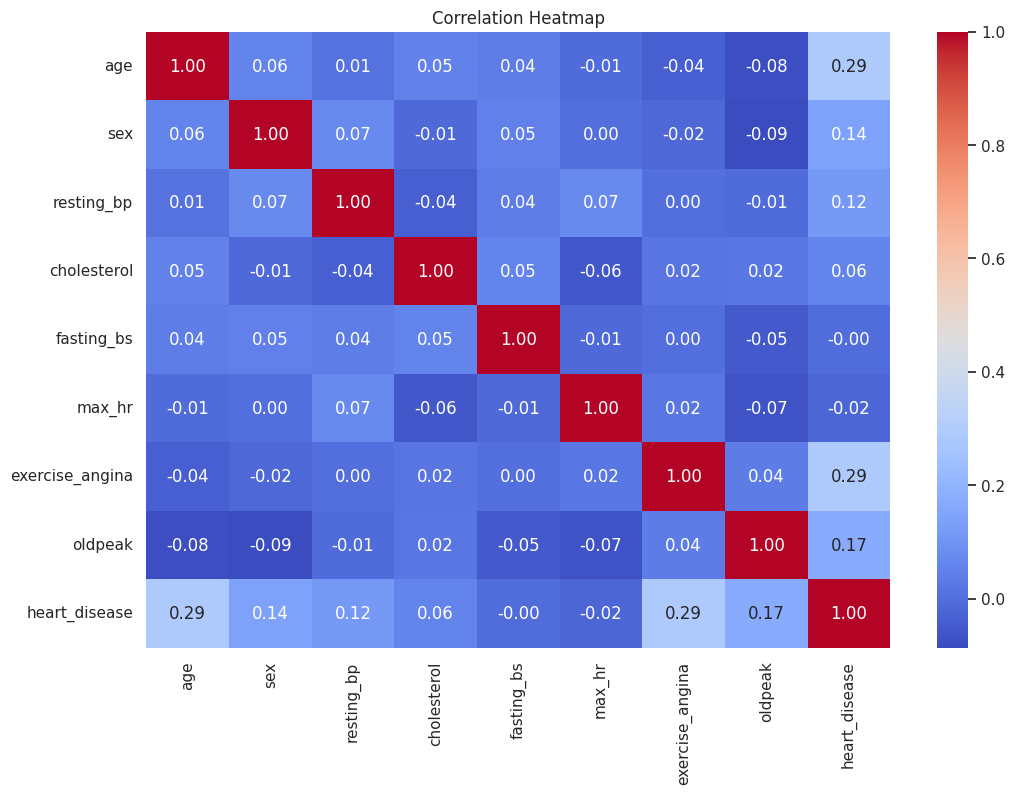

In [19]:
# Viz 2 - Correlation Heatmap

plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Correlation Heatmap

The heatmap shows the relationships between features.

- Features strongly correlated (closer to +1.00 or -1.00) with heart_disease are likely important predictors.
- Some variables may be highly correlated with each other, indicating multicollinearity.

This helps in feature selection and understanding the dataset structure.

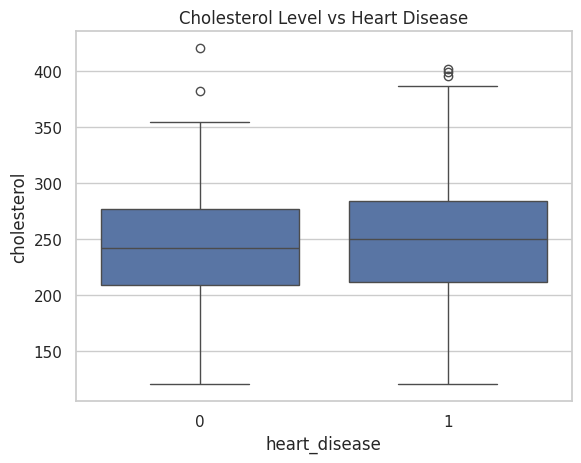

In [20]:
# Viz 3 -  Cholesterol vs Heart_disease

sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.title("Cholesterol Level vs Heart Disease")
plt.show()

## Interpretation: Cholesterol vs Heart Disease

The plot compares cholesterol levels between patients with and without heart disease.

- Patients with heart disease tend to show slightly similar cholesterol levels compared to those without the disease.
- There is significant overlap between the two groups, indicating that cholesterol alone may not be sufficient to predict heart disease.

This suggests that while cholesterol may contribute to heart disease risk, it should be considered along with other features for accurate prediction.

In [31]:
#part 3 - Data Processing

# Check missing values
df.isnull().sum()

# Define columns properly
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope',
            'sex', 'fasting_bs', 'exercise_angina']

num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

# Fill numerical with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#df.isnull().sum()

## Missing Value Handling

Missing values are handled using median imputation for numerical features and mode imputation for categorical features.

- Median is used for numerical columns as it is robust to outliers.
- Mode is used for categorical columns to preserve the most frequent category.

This ensures no data is lost while maintaining the integrity of the dataset.

In [22]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.head()

,age,resting_bp,cholesterol,max_hr,oldpeak,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up,sex_1,fasting_bs_1,exercise_angina_1
737,63,142.0,301.0,162,0.8,False,True,False,True,False,False,True,True,False,False
519,39,153.0,225.0,202,1.1,False,False,False,True,False,False,False,False,False,True
3,72,114.0,177.0,150,1.0,False,False,False,False,True,False,True,True,False,False
600,51,141.0,178.0,138,1.1,False,False,False,True,False,True,False,True,False,False
654,45,113.0,214.0,191,1.0,False,False,True,False,True,False,True,False,False,False


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Recalculate numeric columns AFTER encoding
num_cols_scaled = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

# Apply scaling
X_train[num_cols_scaled] = scaler.fit_transform(X_train[num_cols_scaled])
X_test[num_cols_scaled] = scaler.transform(X_test[num_cols_scaled])

In [24]:
# part 4 - Model training

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [25]:
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

In [26]:
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [27]:
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

In [28]:
for name, model in models.items():
    print(f"{name} trained successfully")

Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully


## Model Training

Three classification models were trained on the dataset:

- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

All models were trained using the training dataset with a fixed random_state of 42 to ensure reproducibility.

The .fit() method was used to allow each model to learn patterns between the input features and the target variable.

In [29]:
# part 5  - model evaluation

from sklearn.metrics import confusion_matrix, classification_report

for name, model in models.items():

    print(f"\n{name}")
    print("-" * 30)

    # Predictions
    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


Decision Tree
------------------------------
Confusion Matrix:
 [[57 22]
 [25 56]]

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
------------------------------
Confusion Matrix:
 [[61 18]
 [16 65]]

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.77      0.78        79
           1       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
------------------------------
Confusion Matrix:
 [[60 19]
 [19 62]]

Classification Report:

              p

## Best Model Selection

Based on the evaluation metrics, the Gradient Boosting model performs best as it achieves the highest F1-score and recall. This indicates a better balance between precision and recall while minimizing false negatives, which is critical in medical diagnosis.

In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        79
           1       0.77      0.77      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160

